# Hierarchical Robustness Analysis

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, confusion_matrix, accuracy_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})

## 1. Data Loading

In [2]:
coords_file = '../data/COORDINATE_XY.csv'
class_file = '../data/classification.csv'
conn_file = '../data/connections.csv'

coords = pd.read_csv(coords_file)
classification = pd.read_csv(class_file)

df = coords.merge(classification[['root_id', 'super_class']], on='root_id', how='inner')
df.rename(columns={'y_coord': 'score', 'super_class': 'target'}, inplace=True)

# Encode the target labels
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df['target']) 

df_conn = pd.read_csv(conn_file)
df_conn = df_conn[df_conn['syn_count'] > 0]  # Filtering as in compute.py

print(f"Neurons: {len(df):,}")
print(f"Connections: {len(df_conn):,}")

Neurons: 134,181
Connections: 3,869,878


## 2. Metrics

In [3]:
def discretize_dt(df_in, k):
    """same as in levels.py"""
    X = df_in[['score']].values
    y = df_in['target_encoded'].values
    
    dt = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=k, min_samples_leaf=50, random_state=42)
    dt.fit(X, y)
    
    leaf_ids = dt.apply(X)
    df_temp = pd.DataFrame({'score': df_in['score'], 'leaf': leaf_ids})
    leaf_order = df_temp.groupby('leaf')['score'].mean().sort_values(ascending=False).index
    
    leaf_to_lvl = {leaf: i + 1 for i, leaf in enumerate(leaf_order)}
    return np.array([leaf_to_lvl[l] for l in leaf_ids])

def discretize_kmeans(df_in, k):
    X = df_in[['score']].values
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    order = np.argsort(-km.cluster_centers_.flatten())
    mapping = {old: new for new, old in enumerate(order, start=1)}
    return np.array([mapping[l] for l in labels])

def discretize_gmm(df_in, k):
    X = df_in[['score']].values
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X)
    order = np.argsort(-gmm.means_.flatten())
    mapping = {old: new for new, old in enumerate(order, start=1)}
    return np.array([mapping[l] for l in labels])

def get_metrics(df_in, levels_array, edges):
    y_true = df_in['target_encoded'] 
    scores = df_in['score']
    
    # Purity
    cm = confusion_matrix(y_true, levels_array)
    purity = np.sum(np.amax(cm, axis=0)) / np.sum(cm)
    
    # NMI
    nmi = normalized_mutual_info_score(y_true, levels_array)
    
    # Accuracy
    df_tmp = pd.DataFrame({'t': y_true, 'l': levels_array})
    majority = df_tmp.groupby('l')['t'].agg(lambda x: x.mode()[0]).to_dict()
    acc = accuracy_score(y_true, df_tmp['l'].map(majority))
    
    # Kruskal-Wallis
    groups = [scores[levels_array == l] for l in np.unique(levels_array)]
    h_stat, _ = stats.kruskal(*groups)
    
    # Feedback Ratio
    id_to_lvl = dict(zip(df_in['root_id'], levels_array))
    l_pre = edges['pre_root_id'].map(id_to_lvl).values
    l_post = edges['post_root_id'].map(id_to_lvl).values
    mask = ~(np.isnan(l_pre) | np.isnan(l_post))
    lp, lq, w = l_pre[mask], l_post[mask], edges['syn_count'].values[mask]
    
    ff = np.sum(w[lp < lq])
    fb = np.sum(w[lp > lq])
    fb_ratio = fb / (ff + fb) if (ff+fb)>0 else 0
    
    return acc, purity, nmi, h_stat, fb_ratio

## 3. Elbow Plot ($k \in \{3,4,5,6,7\}$)

,k,Accuracy,Purity,NMI,Kruskal_H,FB_Ratio
0,3,0.666547,0.666547,0.175550,90359.105950,0.213610
1,4,0.666547,0.666547,0.179754,91373.005162,0.226494
2,5,0.666547,0.666547,0.158116,123060.229815,0.236928
3,6,0.676020,0.676020,0.157383,123158.757616,0.239528
4,7,0.676020,0.676020,0.150867,125535.625149,0.246354


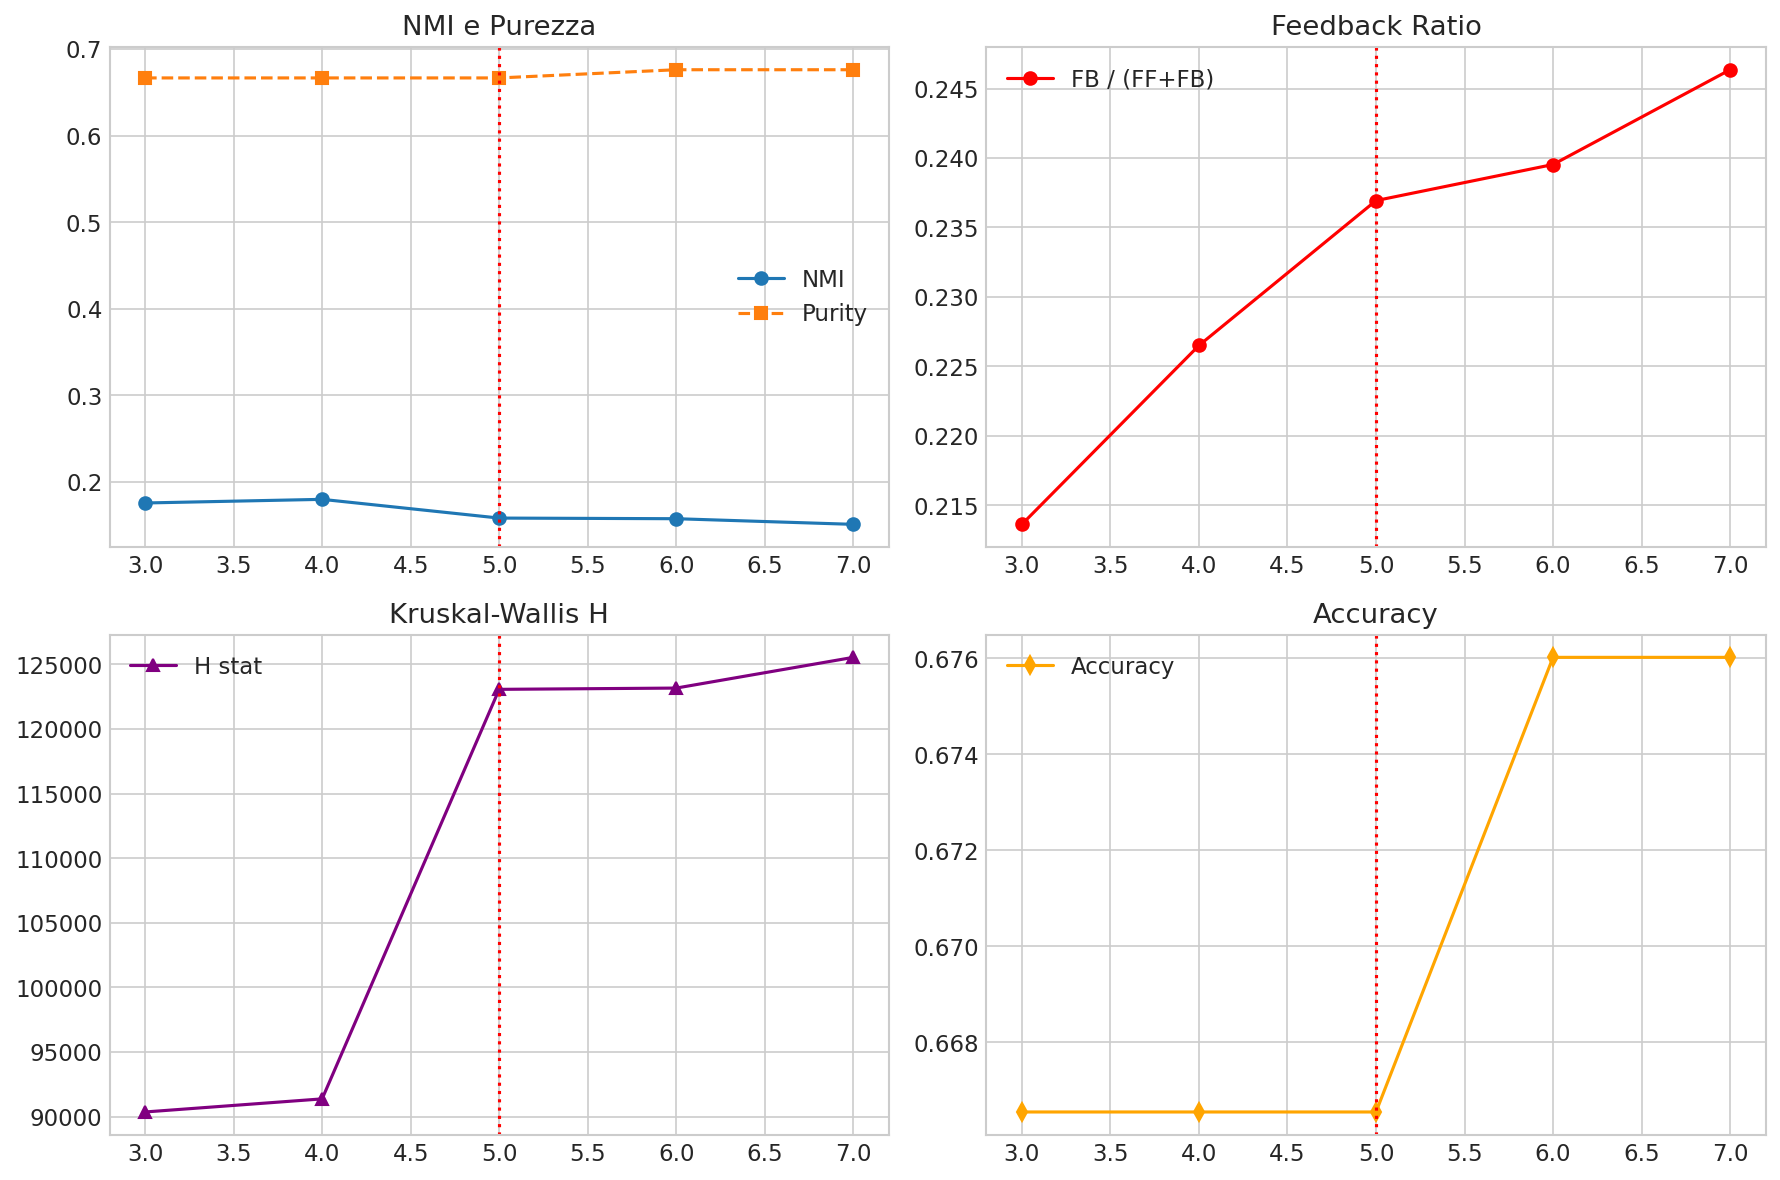

In [4]:
k_vals = [3, 4, 5, 6, 7]
results = []

for k in k_vals:
    lvls = discretize_dt(df, k)
    acc, pur, nmi, h, fbr = get_metrics(df, lvls, df_conn)
    results.append({'k': k, 'Accuracy': acc, 'Purity': pur, 'NMI': nmi, 'Kruskal_H': h, 'FB_Ratio': fbr})

df_res = pd.DataFrame(results)
display(df_res)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(df_res['k'], df_res['NMI'], 'o-', label='NMI')
axes[0,0].plot(df_res['k'], df_res['Purity'], 's--', label='Purity')
axes[0,0].axvline(5, color='red', linestyle=':')
axes[0,0].set_title('NMI e Purezza'); axes[0,0].legend()

axes[0,1].plot(df_res['k'], df_res['FB_Ratio'], 'ro-', label='FB / (FF+FB)')
axes[0,1].axvline(5, color='red', linestyle=':')
axes[0,1].set_title('Feedback Ratio'); axes[0,1].legend()

axes[1,0].plot(df_res['k'], df_res['Kruskal_H'], '^-', color='purple', label='H stat')
axes[1,0].axvline(5, color='red', linestyle=':')
axes[1,0].set_title('Kruskal-Wallis H'); axes[1,0].legend()

axes[1,1].plot(df_res['k'], df_res['Accuracy'], 'd-', color='orange', label='Accuracy')
axes[1,1].axvline(5, color='red', linestyle=':')
axes[1,1].set_title('Accuracy'); axes[1,1].legend()

plt.tight_layout()
plt.savefig('ElbowPlot.png')
plt.show()

## 4. DT vs K-Means ($k=5$)

In [5]:
# K-Means (k=5)
lvls_km = discretize_kmeans(df, 5)
acc_km, pur_km, nmi_km, h_km, fbr_km = get_metrics(df, lvls_km, df_conn)

# GMM (k=5)
lvls_gmm = discretize_gmm(df, 5)
acc_gmm, pur_gmm, nmi_gmm, h_gmm, fbr_gmm = get_metrics(df, lvls_gmm, df_conn)

comp = [
    df_res[df_res['k']==5].iloc[0].to_dict(),
    {'k': 5, 'Accuracy': acc_km, 'Purity': pur_km, 'NMI': nmi_km, 'Kruskal_H': h_km, 'FB_Ratio': fbr_km},
    {'k': 5, 'Accuracy': acc_gmm, 'Purity': pur_gmm, 'NMI': nmi_gmm, 'Kruskal_H': h_gmm, 'FB_Ratio': fbr_gmm}
]

df_comp = pd.DataFrame(comp, index=['Decision Tree', 'K-Means', 'Gaussian Mixture'])
display(df_comp)

,k,Accuracy,Purity,NMI,Kruskal_H,FB_Ratio
Decision Tree,5.0,0.666547,0.666547,0.158116,123060.229815,0.236928
K-Means,5.0,0.643385,0.643385,0.146460,117655.812420,0.237610
Gaussian Mixture,5.0,0.629001,0.629001,0.146928,112198.133086,0.280654
